# Customer Segmentation with RFM, PCA & K-Means

This project segments ~4,300 customers of a UK online retailer into actionable groups using **RFM analysis**, **PCA**, and **k-means clustering**.

**Key finding:** ~5% of customers drive ~48% of total revenue.

**Dataset:** UCI Online Retail — real transactions from a UK gift retailer, 2010–2011 (~541,000 rows).

**Approach:** Load → clean → engineer RFM features → scale → PCA → k-means → profile segments → quantify revenue concentration.

## 1. Load the Data
Download the UCI Online Retail dataset directly from source and load it into a pandas DataFrame. The raw data contains ~541,000 transaction records.

In [1]:
import pandas as pd
import urllib.request
import zipfile
import io


url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))


excel_name = zip_file.namelist()[0]
df = pd.read_excel(zip_file.open(excel_name))

print("Number of rows:", len(df))
df.head()

Number of rows: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Inspect the Data
Check the structure, data types, and missing values. This reveals that ~135,000 rows have no CustomerID — which we'll need to remove, since we can't segment unidentifiable customers.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 3. Clean the Data
Remove rows we can't use: transactions with no CustomerID, cancelled orders (negative quantities, invoice codes starting with "C"), and invalid zero/negative prices. This reduces the data to ~398,000 valid sales.

In [3]:
df_clean = df.dropna(subset=['CustomerID'])

print("Rows before cleaning:", len(df))
print("Rows after removing missing CustomerID:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Rows before cleaning: 541909
Rows after removing missing CustomerID: 406829
Rows removed: 135080


In [4]:
cancelled = df_clean[df_clean['Quantity'] < 0]
print("Rows with negative quantity:", len(cancelled))
cancelled.head()

Rows with negative quantity: 8905


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [5]:
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print("Rows after removing cancellations and junk:", len(df_clean))

Rows after removing cancellations and junk: 397884


In [6]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 4. Feature Engineering — RFM
Collapse the transaction-level data to one row per customer, with three behavioural features: **Recency** (days since last purchase), **Frequency** (number of orders), and **Monetary** (total spend).

In [7]:
import datetime as dt


reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print("Reference date (our 'today'):", reference_date)

# Build the RFM table: one row per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})

# Rename the columns to clear names
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("Number of customers:", len(rfm))
rfm.head()

Reference date (our 'today'): 2011-12-10 12:50:00
Number of customers: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## 5. Scale the Features
The three features sit on very different ranges (Monetary reaches the hundreds of thousands, Frequency stays in single digits). Standardising them ensures each contributes fairly to the distance-based clustering.

In [8]:
from sklearn.preprocessing import StandardScaler

# Scale the three features so they're on a comparable range
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Showing the result as a tidy table
import pandas as pd
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
print("Scaled data (mean ~0, spread comparable across columns):")
rfm_scaled_df.head()

Scaled data (mean ~0, spread comparable across columns):


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


## 6. PCA
Reduce the three features to two principal components for visualisation, retaining ~86% of the variance.

In [9]:
from sklearn.decomposition import PCA

# Apply PCA to the scaled RFM data
pca = PCA()
pca_result = pca.fit_transform(rfm_scaled)

# How much variance (information) does each principal component capture?
explained = pca.explained_variance_ratio_
print("Variance explained by each component:")
for i, ratio in enumerate(explained, 1):
    print(f"  PC{i}: {ratio:.1%}")
print(f"\nFirst two components together: {explained[0] + explained[1]:.1%}")

Variance explained by each component:
  PC1: 55.5%
  PC2: 30.2%
  PC3: 14.2%

First two components together: 85.8%


## 7. Choose k (Elbow Method)
Run k-means across a range of cluster counts and plot the inertia. The "elbow" — where the curve flattens — indicates the optimal number of clusters: k=4.

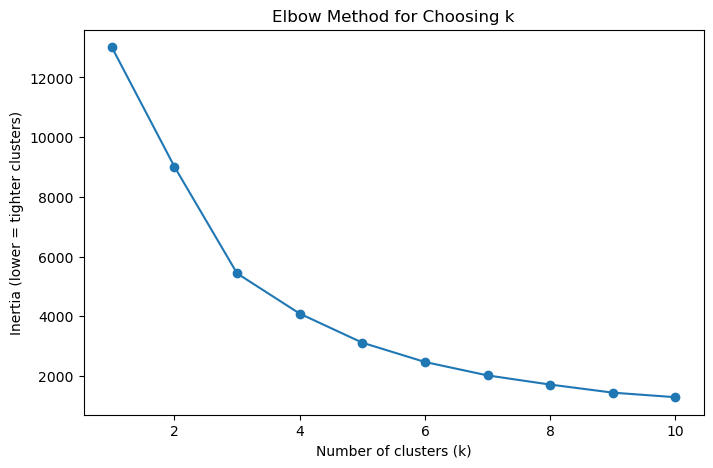

In [10]:
from sklearn.cluster import KMeans

# Try k from 1 to 10 and record how "tight" the clusters are (inertia)
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Plot the elbow curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method for Choosing k')
plt.show()

## 8. K-Means Clustering
Cluster the customers into four segments based on their scaled RFM profiles.

In [11]:
# Run k-means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# How many customers ended up in each cluster?
print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

rfm.head()

Customers per cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


## 9. Profile the Segments
Examine the average RFM values per cluster to characterise each segment: **VIP**, **Loyal High-Value**, **Regular**, and **At-Risk / Lost**.

In [12]:
# Profile each cluster: average Recency, Frequency, Monetary + size
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'})

# Round for readability
cluster_profile = cluster_profile.round(1)
print("Average profile of each cluster:")
cluster_profile

Average profile of each cluster:


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,43.7,3.7,1359.0,3054
1,248.1,1.6,480.6,1067
2,7.4,82.5,127338.3,13
3,15.5,22.3,12709.1,204


## 10. Key Finding — Revenue Concentration
Quantify how much revenue each segment drives. The headline result: ~5% of customers (the VIP and Loyal segments) account for ~48% of total revenue.

In [13]:
# What share of total revenue does each cluster drive?
revenue_by_cluster = rfm.groupby('Cluster')['Monetary'].sum()
total_revenue = rfm['Monetary'].sum()
revenue_share = (revenue_by_cluster / total_revenue * 100).round(1)

print("Revenue share by cluster (%):")
print(revenue_share)

# Top two clusters (VIPs + Loyal) combined
top_share = revenue_share[2] + revenue_share[3]
top_count = rfm['Cluster'].isin([2, 3]).sum()
print(f"\nClusters 2 + 3: {top_count} customers ({top_count/len(rfm)*100:.1f}% of customers)")
print(f"...drive {top_share:.1f}% of total revenue")

Revenue share by cluster (%):
Cluster
0    46.6
1     5.8
2    18.6
3    29.1
Name: Monetary, dtype: float64

Clusters 2 + 3: 217 customers (5.0% of customers)
...drive 47.7% of total revenue


## 11. Visualise the Segments
Plot all customers on the two principal components, coloured by segment, to see the cluster structure — note how the VIP customers sit far apart from the main group.

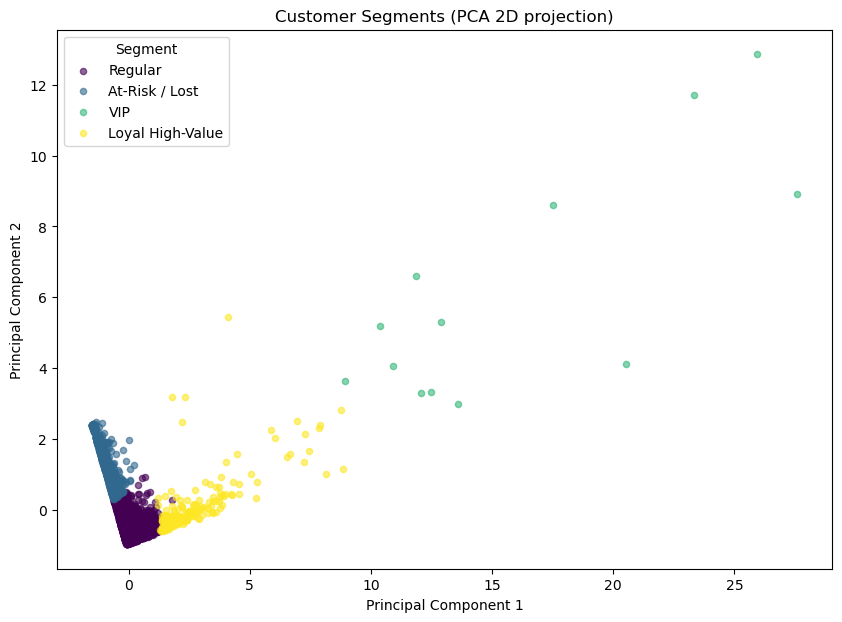

In [15]:
import matplotlib.pyplot as plt

# Recompute the 2D PCA coordinates (same as before)
pca_2d = PCA(n_components=2)
coords = pca_2d.fit_transform(rfm_scaled)

# Give each cluster number a meaningful name and a colour
cluster_names = {
    0: 'Regular',
    1: 'At-Risk / Lost',
    2: 'VIP',
    3: 'Loyal High-Value'
}
cluster_colors = {
    0: '#440154',   # dark purple
    1: '#31688e',   # blue
    2: '#35b779',   # green
    3: '#fde725'    # yellow
}

plt.figure(figsize=(10, 7))

# Plot each cluster separately so it gets its own labelled legend entry
for cluster_id, name in cluster_names.items():
    mask = rfm['Cluster'] == cluster_id          # rows belonging to this cluster
    plt.scatter(coords[mask, 0], coords[mask, 1],
                c=cluster_colors[cluster_id],
                label=name, s=20, alpha=0.6)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments (PCA 2D projection)')
plt.legend(title='Segment')   # discrete legend instead of the gradient bar
plt.savefig('customer_segments_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save the customer segments to a CSV file
rfm.to_csv('customer_segments.csv')
print("Saved! File: customer_segments.csv")
print(f"{len(rfm)} customers with their RFM values and cluster labels")

Saved! File: customer_segments.csv
4338 customers with their RFM values and cluster labels
